# NM-SCRC — Experiments

Whole experimental pipeline. Reusable
domain logic lives in the importable `nmscrc/` package; this notebook **orchestrates** it and renders
all figures inline. Run top-to-bottom: Stage 0 (frozen+hashed) and Stage 2 (100-rep) are cache-aware
(`FORCE`/`FORCE_EXP`). Decisions: split 30/70 quantile grids; selector g=max_k p_k; head-to-head uses
the `search` optimisation layer, Exp5/RAND use `pinned`.

## Setup

In [1]:
# ===== v3 run: version-prefix scheme (all generated files -> v2_*); v1 left untouched =====
import os
os.environ["NMSCRC_VERSION"] = "v3"            # output prefix v3_
os.environ["NMSCRC_RAW_DIR"] = "data-full_v3"  # raw pool files: v3
# ========================================================================================
import sys, json, glob
from pathlib import Path
import numpy as np, pandas as pd
ROOT = Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from nmscrc import paths, check_paths, data, parser, losses, repeng, judge, results, stage0, hashing
from nmscrc import experiments as E, plots
from nmscrc.artifacts import build_grids
from nmscrc.methods import nmscrc_i, nmscrc_t
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.3,"font.size":11,
                     "axes.spines.top":False,"axes.spines.right":False})
cfg = paths.load_config(); FORCE = False; FORCE_EXP = False
methods = data.load_method_list()
print("roots:", paths.resolved_roots()); print("models:", cfg["models"], "| grid:", cfg["grids"]["lambda1"]["mode"])

roots: {'PROJECT_ROOT': 'C:\\Documents\\STUDY\\MATHS\\Year 4\\M4R\\code', 'DATA_ROOT': 'C:\\Documents\\STUDY\\MATHS\\Year 4\\M4R\\code\\data', 'RESULTS_ROOT': 'C:\\Documents\\STUDY\\MATHS\\Year 4\\M4R\\code\\results', 'SPLIT_NAME': 'pool_probe30calibtest70', 'raw_dir': 'data-full_v3'}
models: ['llama3_2_1b', 'llama3_2_3b', 'llama3_1_8b'] | grid: quantile


### Preflight

In [2]:
check_paths.check_inputs()

[paths] resolved roots:
    PROJECT_ROOT  = C:\Documents\STUDY\MATHS\Year 4\M4R\code
    DATA_ROOT     = C:\Documents\STUDY\MATHS\Year 4\M4R\code\data
    RESULTS_ROOT  = C:\Documents\STUDY\MATHS\Year 4\M4R\code\results
    SPLIT_NAME    = pool_probe30calibtest70
    raw_dir       = data-full_v3

[preflight] checking 7 INPUT files for models ['llama3_2_1b', 'llama3_2_3b', 'llama3_1_8b'] ...
    [ok ] C:\Documents\STUDY\MATHS\Year 4\M4R\code\data\data-full_v3\llama3_2_1b_pool_data.csv
    [ok ] C:\Documents\STUDY\MATHS\Year 4\M4R\code\data\data-full_v3\llama3_2_1b_pool_hs.npy
    [ok ] C:\Documents\STUDY\MATHS\Year 4\M4R\code\data\data-full_v3\llama3_2_3b_pool_data.csv
    [ok ] C:\Documents\STUDY\MATHS\Year 4\M4R\code\data\data-full_v3\llama3_2_3b_pool_hs.npy
    [ok ] C:\Documents\STUDY\MATHS\Year 4\M4R\code\data\data-full_v3\llama3_1_8b_pool_data.csv
    [ok ] C:\Documents\STUDY\MATHS\Year 4\M4R\code\data\data-full_v3\llama3_1_8b_pool_hs.npy
    [ok ] C:\Documents\STUDY\MATHS\Year 4\

True

### Gate-1 — migration faithful

In [3]:
mset=set(methods); m0,m1=methods[0],methods[14]
def legacy_parse(raw,mset):
    s="" if pd.isna(raw) else str(raw); c='{"methods": ["'+s.strip(); c=c.rstrip()
    if c.endswith("."): c=c[:-1]
    try:
        sel=json.loads(c).get("methods",[]); return [x for x in sel if x in mset] if isinstance(sel,list) else []
    except Exception: return []
ok=True
ok&=data.parse_methods_from_results(f"[{{'method':'{m0}','conclusion':'applicable','f':false}}]")==[m0]
ok&=data.parse_methods_from_results(f"[{{'method':'{m0}','conclusion':'applicable'}},{{'method':'{m1}','conclusion':'Not applicable'}}]")==[m0]
ok&=data.parse_methods_from_results(f"[{{'method':'{m0}.','conclusion':'applicable'}}]")==[m0]
ok&=parser.parse_methods(f'{m1}"]}}',mset)==[m1]; parser.assert_echo_pattern_safe(methods)
real=pd.read_csv(paths.data_full("llama3_2_3b"),usecols=["model_answer"]).head(300)["model_answer"]
mm=int(sum(parser.parse_methods(r,mset)!=legacy_parse(r,mset) for r in real))
print("Gate-1:", "PASS" if (ok and mm==0) else "FAIL", "| new-vs-legacy mismatches/300:", mm); assert ok and mm==0

Gate-1: PASS | new-vs-legacy mismatches/300: 0


## Stage 0 — frozen upstream: split -> probe(freeze) -> scores+answer+loss_tensor.
Quantile per-model grids; cache-aware.

In [4]:
stage0.stage0a_split(cfg, force=FORCE)
stage0.stage0b_probe(cfg, force=FORCE)
answer_flags = stage0.stage0c_scores(cfg, force=FORCE)
print("probe val_macro_auc:", {m: round(json.loads(paths.probe_meta(m).read_text())["val_macro_auc"],4) for m in cfg["models"]})

[0a] llama3_2_1b: split exists -> skip
[0a] llama3_2_3b: split exists -> skip
[0a] llama3_1_8b: split exists -> skip
[0b] llama3_2_1b: frozen-probe logits exist -> skip
[0b] llama3_2_3b: frozen-probe logits exist -> skip
[0b] llama3_1_8b: frozen-probe logits exist -> skip


[0c] llama3_2_1b: echo_rate=0.0000 ok_rate=0.6627 allzero=2745/8137 | lam1[0.000,0.977] lam2[0.000,1.000] | loss_tensor saved


[0c] llama3_2_3b: echo_rate=0.2183 ok_rate=0.7751 allzero=1830/8137 | lam1[0.000,0.942] lam2[0.000,1.000] | loss_tensor saved


[0c] llama3_1_8b: echo_rate=0.0006 ok_rate=0.9932 allzero=55/8137 | lam1[0.000,0.992] lam2[0.000,1.000] | loss_tensor saved
probe val_macro_auc: {'llama3_2_1b': 0.9987, 'llama3_2_3b': 0.9994, 'llama3_1_8b': 0.9997}


## ━━ CHECKPOINT 1 — parsers + pipeline shape ━━
(1) Y from `results` not `model_answer`; (2) raw-LLM parser on 3B echoes -> echo_rate, echoed rows
all-zero (not dropped); (3) one rung/one rep of exp① NM-SCRC-I-EB, probe FROZEN.

In [5]:
print("="*70); print("CHECKPOINT 1"); print("="*70)
M="llama3_2_1b"; Y3=data.build_multi_hot_labels(pd.read_csv(paths.split_data(M,"calibtest")).head(3),methods)
print("(1) Y from results:"); [print("   row",i,"->",[methods[k] for k in np.where(Y3[i]>0)[0]]) for i in range(3)]
fix=['m1", "m2", "m3"]}','method_1"]}','<method>"]}',f'{methods[14]}"]}}']
am,fl,rt=parser.build_answer_matrix(pd.DataFrame({"model_answer":fix}),methods)
print("(2) echo fixture:"); [print(f"   {fix[i][:20]!r:24s} flag={fl.iloc[i]:9s} pred={int(am.iloc[i].sum())}") for i in range(len(fix))]
print(f"   REAL 3B echo_rate={answer_flags['llama3_2_3b']['echo_rate']:.4f} (1b={answer_flags['llama3_2_1b']['echo_rate']:.4f} 8b={answer_flags['llama3_1_8b']['echo_rate']:.4f})")
A=stage0.build_or_load_artifacts(M,cfg); xi=cfg["targets"]["xi_default"]
ell,_=losses.oracle_ell_star(A.g,A.Y,A.L_f1,A.lambda1,A.lambda2,xi); alpha=ell+0.05
c,t=repeng.rep_split(A.n,0,cfg["rep_split"]["calib_frac_of_pool"])
r=nmscrc_i.run(A,c,t,xi,alpha,cfg["delta"],"eb","search")
print(f"(3) exp1 NM-SCRC-I-EB 1b rep0: state={judge.rep_state(r['abstained'],r['risk_cond'],alpha)} "
      f"cov={r['coverage']:.3f} risk={r['risk_cond']:.4f} set={r['set_size']:.3f} cert={r['cert_half_width']:.4f}")

CHECKPOINT 1


(1) Y from results:
   row 0 -> ['Kolmogorov-Smirnov Test']
   row 1 -> ['Kendall Correlation Coefficient']
   row 2 -> ['Partial Correlation Coefficient']
(2) echo fixture:
   'm1", "m2", "m3"]}'      flag=echo      pred=0
   'method_1"]}'            flag=echo      pred=0
   '<method>"]}'            flag=echo      pred=0
   'Mantel-Haenszel Test'   flag=ok        pred=1
   REAL 3B echo_rate=0.2183 (1b=0.0000 8b=0.0006)


(3) exp1 NM-SCRC-I-EB 1b rep0: state=PASS cov=0.561 risk=0.0322 set=1.642 cert=0.0257


## Stage 0d-0e — qc_3b (transition vs degenerate) + freeze/hash.

In [6]:
qc = stage0.stage0d_qc(cfg)
SPLIT_HASH = stage0.stage0e_freeze(cfg)
assert hashing.check_hash(paths.artifact_hash(), paths.DATA_ROOT) == SPLIT_HASH
print("SPLIT_HASH =", SPLIT_HASH)

[0d] qc_3b: K/M(M=20)= 1b=0.000, 3b=0.900, 8b=0.000; use_3b_for_transition(tentative)=False; exp6 rung=llama3_1_8b


[0e] froze 54 files; combined sha256=9b4b7896fcc09c32... -> v3_ARTIFACT_HASH.txt


SPLIT_HASH = 9b4b7896fcc09c324ae640665fee5e17e1d068e6a58581d71199d2c123010c4a


## ━━ CHECKPOINT 2 — Stage 0 frozen + qc verdict ━━

In [7]:
qc=json.loads(paths.qc_3b().read_text())
print("(1) qc_3b:", qc["transition_condition"])
for m in cfg["models"]: print(f"   {m:12s} K/M vs M:", " ".join(f"{k}:{v:.2f}" for k,v in qc["K_over_M_vs_M"][m].items()))
print(f"   use_3b_for_transition={qc['use_3b_for_transition']} (axis: {qc['transition_axis']}); exp6 rung={qc['exp6_primary_rung']}")
print("(2) hash:", hashing.read_combined_hash(paths.artifact_hash()))
for m in cfg["models"]:
    a=answer_flags[m]; print(f"   {m:12s} echo={a['echo_rate']:.4f} unparseable={a['unparseable_rate']:.4f} ok={a['ok_rate']:.4f}")

(1) qc_3b: K>0 iff delta < (alpha+B)/M  (Eq 4.3, B=1)
   llama3_2_1b  K/M vs M: 20:0.00 40:0.00 80:0.00 160:0.99 320:0.00 640:0.00 1280:0.00 8137:1.00
   llama3_2_3b  K/M vs M: 20:0.90 40:0.00 80:0.00 160:0.00 320:0.00 640:0.00 1280:0.00 8137:0.00
   llama3_1_8b  K/M vs M: 20:0.00 40:0.90 80:0.00 160:0.00 320:0.00 640:0.00 1280:0.00 8137:0.00
   use_3b_for_transition=False (axis: bag-size M (NOT the m2 axis of exp6)); exp6 rung=llama3_1_8b
(2) hash: 9b4b7896fcc09c324ae640665fee5e17e1d068e6a58581d71199d2c123010c4a
   llama3_2_1b  echo=0.0000 unparseable=0.3322 ok=0.6627
   llama3_2_3b  echo=0.2183 unparseable=0.0042 ok=0.7751
   llama3_1_8b  echo=0.0006 unparseable=0.0007 ok=0.9932


## Stage 1 + Stage 2 — run all experiments (per-rep -> results/*.jsonl). Cache-aware
(set `FORCE_EXP=True` to recompute, ~8 min). Stage 1 synthetic (⑨ floor, union-tax) has no model
dependency; Stage 2 reads the frozen artifacts and re-splits the calibtest pool per rep.

In [8]:
have = (len(glob.glob(str(paths.results_dir("head2head")/f"{paths.out_version()}_*.jsonl")))>0
        and len(glob.glob(str(paths.results_dir("mono_gridrefine")/f"{paths.out_version()}_*.jsonl")))>0)
if FORCE_EXP or not have:
    E.run_synth(cfg)
    E.run_exp1(cfg,SPLIT_HASH); E.run_exp3(cfg,SPLIT_HASH); E.run_exp5(cfg,SPLIT_HASH)
    E.run_exp6(cfg,SPLIT_HASH); E.run_exp8(cfg,SPLIT_HASH); E.run_head2head(cfg,SPLIT_HASH)
    E.run_mono_gridrefine(cfg,SPLIT_HASH)
else:
    print("results/*.jsonl present -> skipping recompute (FORCE_EXP=True to rerun)")

results/*.jsonl present -> skipping recompute (FORCE_EXP=True to rerun)


## ① Validity + PAC histogram (3 rungs, NM-SCRC-I-EB, Δ=0.05). The fraction of reps with
risk ≤ α (or abstain) must be ≥ 1−δ = 0.9.

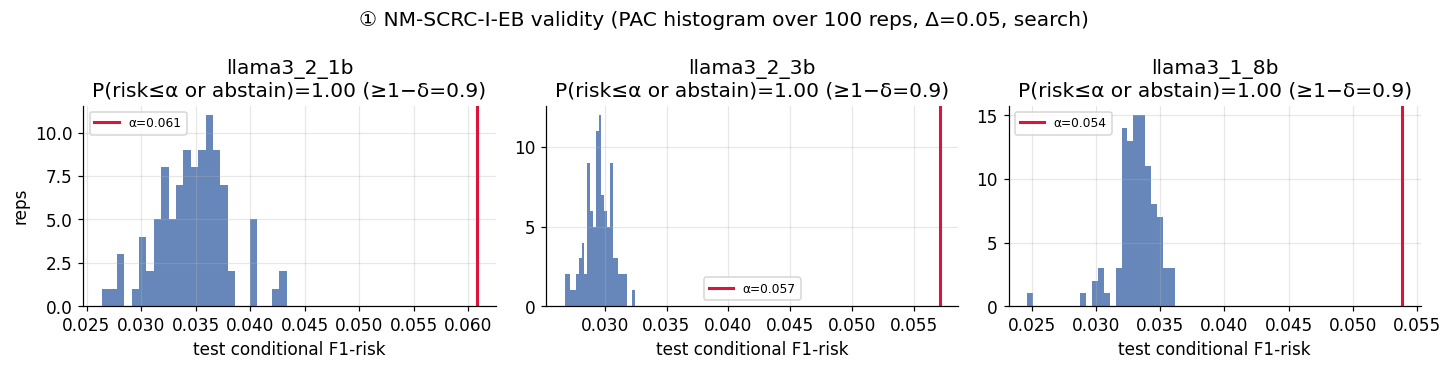

In [9]:
fig=plots.plot_exp1(delta_gap=0.05); plt.show()

## ③ F1-risk is U-shaped in set size (non-monotone) — the property every opponent must respect.

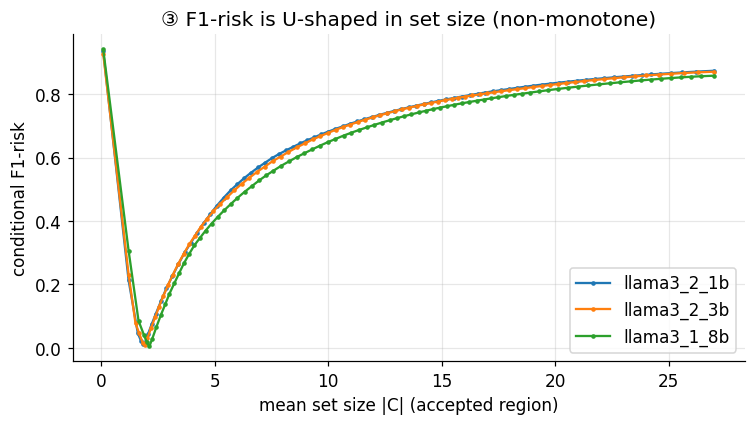

In [10]:
fig=plots.plot_exp3(); plt.show()

## ⑤ ξ-slope (C1): EB certificate decays ~√ in coverage (slope ≈ −0.5..−0.7); Hoeffding pays
1/φ̂ (slope ≈ −1.0). Real 1b + synthetic.

log-log slopes (cert vs coverage): {'llama3_2_1b/eb': np.float64(-0.79), 'llama3_2_1b/hoeffding': np.float64(-1.0), 'synthetic/eb': np.float64(-0.6), 'synthetic/hoeffding': np.float64(-1.0)}


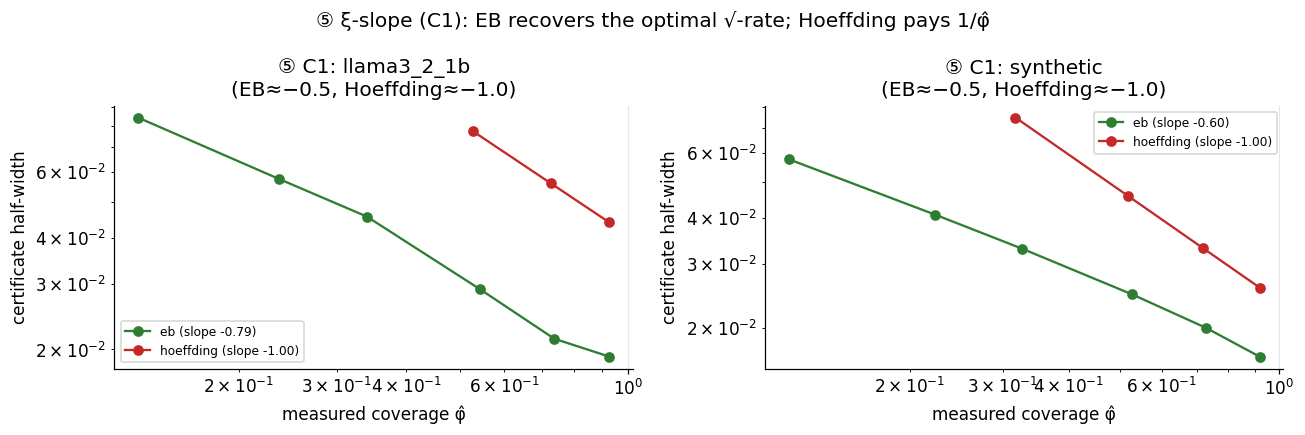

In [11]:
fig,slopes=plots.plot_exp5(); print("log-log slopes (cert vs coverage):",{f'{k[0]}/{k[1]}':round(v,2) for k,v in slopes.items()}); plt.show()

## ⑥ Phase transition vs m₂ (8b): certificate grows and the method eventually abstains as the
Λ₂ union widens.

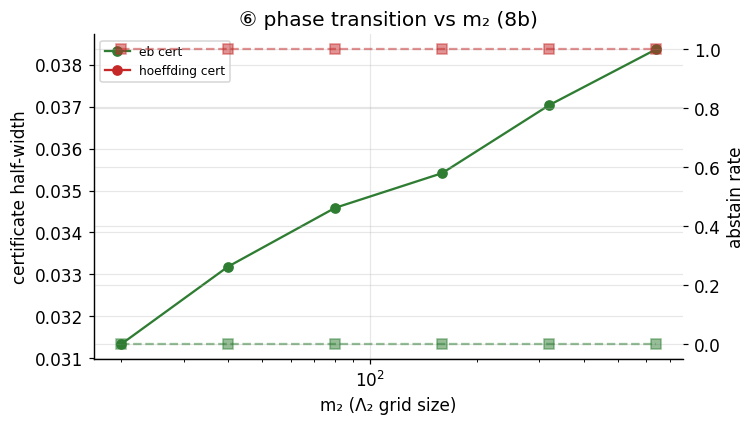

In [12]:
fig=plots.plot_exp6(); plt.show()

## ⑧ NM-SCRC-I vs NM-SCRC-T (1b + 8b): T gives exact coverage; the instability count K/M ≈ 0
on real data (favourable regime). (The small-M / degenerate-loss K/M transition is appendix-only.)

In [13]:
display(plots.plot_exp8())

C:\Documents\STUDY\MATHS\Year 4\M4R\code\nmscrc\plots.py:126: RuntimeWarning: Mean of empty slice
  "mean_K_over_M": np.nanmean([r["K_over_M"] for r in rs if r["K_over_M"] is not None])})


,rung,method,n,abstain_rate,mean_risk,mean_cov,mean_K_over_M
0,llama3_1_8b,nmscrc_i_eb,100,0.0,0.043169,0.340568,NaN
1,llama3_1_8b,nmscrc_t,100,0.0,0.041016,0.300782,0.0
2,llama3_2_1b,nmscrc_i_eb,100,0.0,0.048223,0.338516,NaN
3,llama3_2_1b,nmscrc_t,100,0.0,0.045752,0.299101,0.0


## Stage 1 synthetic — ⑨ feasibility floor (EB feasible at smaller n than Hoeffding) and the
union-tax (certificate ∝ √log(m₁m₂)).

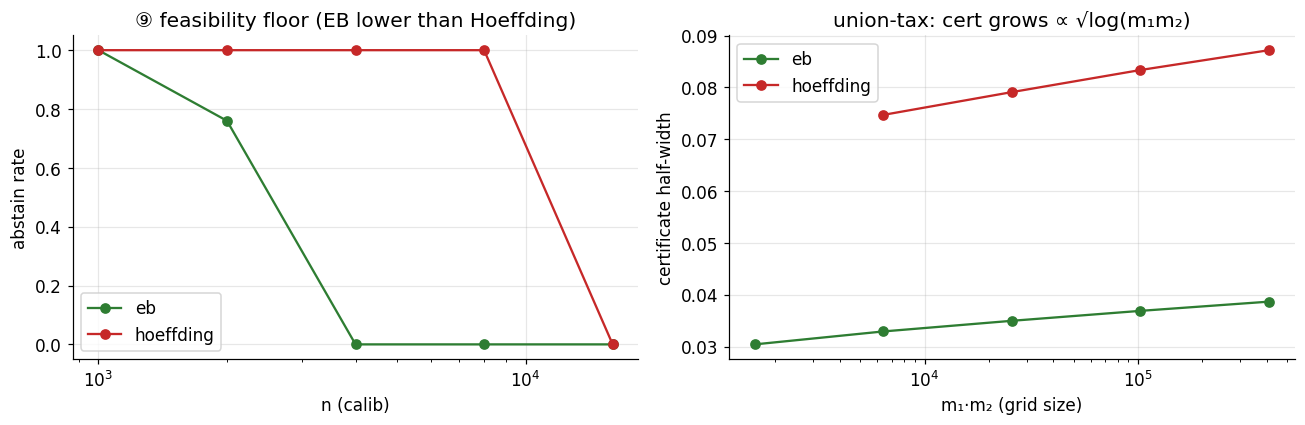

In [14]:
fig=plots.plot_synth(); plt.show()

## Head-to-head (6 judged methods + raw-LLM/RAND floors; `search` mode so the winner's
curse is in play). Real rungs are near-oracle (opponent failures mild); the `synthetic_f1` arm is the
adversarial instance. NM-SCRC-I controls the conditional F1-risk; CRC-NM-marginal is on the MARGINAL
caliber (different column — not comparable to the conditional risk).

In [15]:
h=plots.head2head_table(cfg); display(h)

,rung,method,n_reps,alpha,abstain,mean_risk,mean_cov,mean_set,verdict,ctrl_frac,K_over_M,echo_rate,recall_risk,true_f1_risk
0,llama3_1_8b,nmscrc_i_eb,100,0.0538,0.00,0.0332,0.837,1.657,PASS,1.000,NaN,NaN,NaN,NaN
1,llama3_1_8b,nmscrc_i_hoeff,100,0.0538,0.00,0.0120,0.969,1.768,PASS,1.000,NaN,NaN,NaN,NaN
2,llama3_1_8b,nmscrc_t,100,0.0538,1.00,NaN,NaN,NaN,ABSTAIN,NaN,0.000,NaN,NaN,NaN
3,llama3_1_8b,mono,100,0.0538,0.00,0.0427,0.328,1.862,PASS,1.000,NaN,NaN,NaN,NaN
4,llama3_1_8b,naive,100,0.0538,0.00,0.0514,0.730,1.628,FAIL,0.430,NaN,NaN,NaN,NaN
5,llama3_1_8b,crcnm_marginal,100,0.0538,0.00,0.8556,1.000,26.242,FAIL,0.030,NaN,NaN,NaN,NaN
6,llama3_1_8b,xu_proxy,100,0.0538,0.00,0.0169,0.328,2.002,PASS,1.000,NaN,NaN,0.0265,0.0169
7,llama3_1_8b,raw_llm,100,0.0538,0.00,0.5222,1.000,7.593,floor,NaN,NaN,0.000614,NaN,NaN
8,llama3_1_8b,rand,100,0.0538,0.99,0.0312,0.530,1.728,floor,NaN,NaN,NaN,NaN,NaN
9,llama3_2_1b,nmscrc_i_eb,100,0.0608,0.00,0.0347,0.581,1.659,PASS,1.000,NaN,NaN,NaN,NaN


## Why the non-monotone correction is necessary (single-figure evidence)
As the Λ₂ grid densifies (a stronger search), **mono** (Xu's counting fed F1-loss, **no t_V cushion**)
FAILs — its violation fraction climbs past the δ=0.1 line on **both** rungs. Its benign-PASS at coarse
grids is **grid luck, not validity, and not a probe-strength effect** (1b fails too once the grid is
dense enough). **NM-SCRC-I-EB** (the *same* search, but with the t_V cushion) stays at violation ≈ 0
for every m₂: the cushion immunises against grid refinement. This is the load-bearing motivation for
the Λ-union / t_V correction.

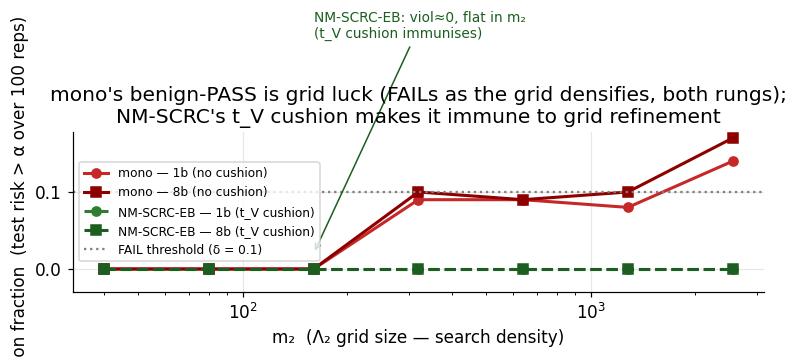

In [16]:
fig = plots.plot_mono_gridrefine(); plt.show()

## C2 transductive LOO certificate: the certificate slides α->α+B (vacuity) as m₂ refines, while the true held-out risk stays ~α; onset (Δ<(α+B)/M) shifts right as M grows. Distinct object from exp6's inductive union-tax on the same m₂ axis.

[c2] m2=80 done


[c2] m2=160 done


[c2] m2=320 done


[c2] m2=640 done


[c2] m2=1280 done


[c2] m2=2560 done


[c2] m2=5120 done


[c2] m2=10240 done


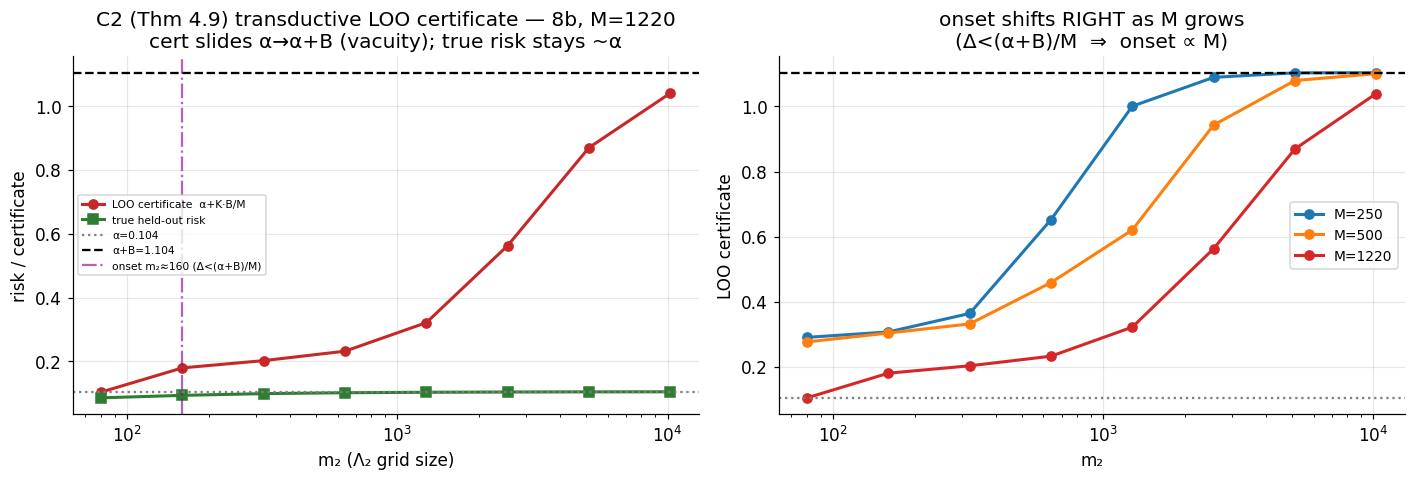

In [17]:
# C2 transductive LOO certificate (added experiment; runs once per version)
if FORCE_EXP or not glob.glob(str(paths.results_dir("c2_transductive_cert")/f"{paths.out_version()}_*.jsonl")):
    E.run_c2(cfg, SPLIT_HASH)
fig = plots.plot_c2_transductive_cert(); plt.show()

# Results record — objective numbers only
All tables below are computed from the frozen `results/*.jsonl`; means/percentiles over the 100 reps. No interpretation.

In [18]:
from nmscrc import summary as SU
pd.set_option("display.width", 240); pd.set_option("display.max_columns", 30); pd.set_option("display.max_rows", 80)
d0 = SU.stage0(cfg)
print("Stage 0 facts | combined_hash =", d0.attrs["combined_hash"], "| use_3b_for_transition =", d0.attrs["use_3b_for_transition"])
display(d0)

Stage 0 facts | combined_hash = 9b4b7896fcc09c324ae640665fee5e17e1d068e6a58581d71199d2c123010c4a | use_3b_for_transition = False


,model,probe_val_auc,input_dim,calibtest_n,ell*(xi=0.3),echo_rate,unparseable,ok_rate,K/M@M20,K/M@M40,K/M@M80
0,llama3_2_1b,0.9987,2048,8137,0.0108,0.0000,0.3322,0.6627,0.0,0.0,0.0
1,llama3_2_3b,0.9994,3072,8137,0.0071,0.2183,0.0042,0.7751,0.9,0.0,0.0
2,llama3_1_8b,0.9997,4096,8137,0.0038,0.0006,0.0007,0.9932,0.0,0.9,0.0


In [19]:
print("① validity — per rung x variant x Delta")
display(SU.exp1(cfg))

① validity — per rung x variant x Delta


,rung,method,Delta,alpha,n_reps,abstain_rate,frac_risk_le_alpha,frac_safe,mean_risk,p05_risk,p95_risk,mean_cov,mean_set,mean_cert,verdict
0,llama3_1_8b,nmscrc_i_eb,0.02,0.0238,100,0.00,1.0,1.0,0.0098,0.0078,0.0121,0.957,1.771,0.0133,PASS
1,llama3_1_8b,nmscrc_i_eb,0.05,0.0538,100,0.00,1.0,1.0,0.0332,0.0305,0.0353,0.837,1.657,0.0190,PASS
2,llama3_1_8b,nmscrc_i_eb,0.10,0.1038,100,0.00,1.0,1.0,0.0671,0.0635,0.0702,0.697,1.586,0.0303,PASS
3,llama3_1_8b,nmscrc_i_hoeffding,0.02,0.0238,100,1.00,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,ABSTAIN
4,llama3_1_8b,nmscrc_i_hoeffding,0.05,0.0538,100,0.00,1.0,1.0,0.0120,0.0090,0.0148,0.969,1.768,0.0410,PASS
5,llama3_1_8b,nmscrc_i_hoeffding,0.10,0.1038,100,0.00,1.0,1.0,0.0516,0.0401,0.0598,0.859,1.622,0.0475,PASS
6,llama3_2_1b,nmscrc_i_eb,0.02,0.0308,100,0.90,1.0,1.0,0.0168,0.0154,0.0188,0.700,1.837,0.0175,PASS
7,llama3_2_1b,nmscrc_i_eb,0.05,0.0608,100,0.00,1.0,1.0,0.0347,0.0293,0.0402,0.581,1.659,0.0257,PASS
8,llama3_2_1b,nmscrc_i_eb,0.10,0.1108,100,0.00,1.0,1.0,0.0631,0.0594,0.0670,0.466,1.512,0.0392,PASS
9,llama3_2_1b,nmscrc_i_hoeffding,0.02,0.0308,100,1.00,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,ABSTAIN


In [20]:
print("③ U-shape (oracle ell*, argmin lambda2)"); display(SU.exp3())
print("⑧ NM-SCRC-I vs NM-SCRC-T (1b + 8b)"); display(SU.exp8())

③ U-shape (oracle ell*, argmin lambda2)


,rung,xi,coverage,min_cond_risk(ell*),argmin_lambda2
0,llama3_2_1b,0.3,0.305,0.0108,0.1545
1,llama3_2_3b,0.3,0.305,0.0080,0.5825
2,llama3_1_8b,0.3,0.305,0.0046,0.4911


⑧ NM-SCRC-I vs NM-SCRC-T (1b + 8b)


,rung,method,alpha,abstain_rate,mean_risk,mean_cov,mean_set,mean_K_over_M
0,llama3_1_8b,nmscrc_i_eb,0.1038,0.0,0.0432,0.341,1.852,NaN
1,llama3_1_8b,nmscrc_t,0.1038,0.0,0.0410,0.301,1.883,0.0
2,llama3_2_1b,nmscrc_i_eb,0.1108,0.0,0.0482,0.339,1.605,NaN
3,llama3_2_1b,nmscrc_t,0.1108,0.0,0.0458,0.299,1.611,0.0


In [21]:
d5, sl = SU.exp5()
print("⑤ xi-slope (C1) — per (rung, variant, xi)"); display(d5)
print("⑤ fitted log-log slopes (cert ~ coverage)"); display(sl)

⑤ xi-slope (C1) — per (rung, variant, xi)


,rung,method,xi,mean_cov,mean_cert,abstain_rate
0,llama3_2_1b,nmscrc_i_eb,0.1,0.132,0.08412,0.0
1,llama3_2_1b,nmscrc_i_eb,0.2,0.236,0.05749,0.0
2,llama3_2_1b,nmscrc_i_eb,0.3,0.340,0.04555,0.0
3,llama3_2_1b,nmscrc_i_eb,0.5,0.542,0.02909,0.0
4,llama3_2_1b,nmscrc_i_eb,0.7,0.738,0.02137,0.0
5,llama3_2_1b,nmscrc_i_eb,0.9,0.927,0.01913,0.0
6,llama3_2_1b,nmscrc_i_hoeffding,0.1,NaN,NaN,1.0
7,llama3_2_1b,nmscrc_i_hoeffding,0.2,NaN,NaN,1.0
8,llama3_2_1b,nmscrc_i_hoeffding,0.3,NaN,NaN,1.0
9,llama3_2_1b,nmscrc_i_hoeffding,0.5,0.527,0.07720,0.0


⑤ fitted log-log slopes (cert ~ coverage)


,rung,method,slope_loglog(cert~cov)
0,llama3_2_1b,nmscrc_i_eb,-0.790
1,synthetic,nmscrc_i_eb,-0.597
2,llama3_2_1b,nmscrc_i_hoeffding,-1.000
3,synthetic,nmscrc_i_hoeffding,-1.000


In [22]:
print("⑥ phase transition (8b) — vs m2"); display(SU.exp6())

⑥ phase transition (8b) — vs m2


,rung,method,m2,abstain_rate,mean_cert,mean_cov
0,llama3_1_8b,nmscrc_i_eb,20,0.0,0.0313,0.341
1,llama3_1_8b,nmscrc_i_eb,40,0.0,0.0332,0.341
2,llama3_1_8b,nmscrc_i_eb,80,0.0,0.0346,0.341
3,llama3_1_8b,nmscrc_i_eb,160,0.0,0.0354,0.341
4,llama3_1_8b,nmscrc_i_eb,320,0.0,0.0370,0.341
5,llama3_1_8b,nmscrc_i_eb,640,0.0,0.0384,0.341
6,llama3_1_8b,nmscrc_i_hoeffding,20,1.0,NaN,NaN
7,llama3_1_8b,nmscrc_i_hoeffding,40,1.0,NaN,NaN
8,llama3_1_8b,nmscrc_i_hoeffding,80,1.0,NaN,NaN
9,llama3_1_8b,nmscrc_i_hoeffding,160,1.0,NaN,NaN


In [23]:
print("head-to-head — 6 judged methods + raw-LLM/RAND floors (CRC-NM-marginal: MARGINAL caliber)")
display(plots.head2head_table(cfg))

head-to-head — 6 judged methods + raw-LLM/RAND floors (CRC-NM-marginal: MARGINAL caliber)


,rung,method,n_reps,alpha,abstain,mean_risk,mean_cov,mean_set,verdict,ctrl_frac,K_over_M,echo_rate,recall_risk,true_f1_risk
0,llama3_1_8b,nmscrc_i_eb,100,0.0538,0.00,0.0332,0.837,1.657,PASS,1.000,NaN,NaN,NaN,NaN
1,llama3_1_8b,nmscrc_i_hoeff,100,0.0538,0.00,0.0120,0.969,1.768,PASS,1.000,NaN,NaN,NaN,NaN
2,llama3_1_8b,nmscrc_t,100,0.0538,1.00,NaN,NaN,NaN,ABSTAIN,NaN,0.000,NaN,NaN,NaN
3,llama3_1_8b,mono,100,0.0538,0.00,0.0427,0.328,1.862,PASS,1.000,NaN,NaN,NaN,NaN
4,llama3_1_8b,naive,100,0.0538,0.00,0.0514,0.730,1.628,FAIL,0.430,NaN,NaN,NaN,NaN
5,llama3_1_8b,crcnm_marginal,100,0.0538,0.00,0.8556,1.000,26.242,FAIL,0.030,NaN,NaN,NaN,NaN
6,llama3_1_8b,xu_proxy,100,0.0538,0.00,0.0169,0.328,2.002,PASS,1.000,NaN,NaN,0.0265,0.0169
7,llama3_1_8b,raw_llm,100,0.0538,0.00,0.5222,1.000,7.593,floor,NaN,NaN,0.000614,NaN,NaN
8,llama3_1_8b,rand,100,0.0538,0.99,0.0312,0.530,1.728,floor,NaN,NaN,NaN,NaN,NaN
9,llama3_2_1b,nmscrc_i_eb,100,0.0608,0.00,0.0347,0.581,1.659,PASS,1.000,NaN,NaN,NaN,NaN


In [24]:
print("⑨ feasibility floor — vs n (calib)"); display(SU.floor())
print("union-tax — vs m1*m2"); display(SU.union_tax())

⑨ feasibility floor — vs n (calib)


,method,n_calib,abstain_rate,mean_cert
0,nmscrc_i_eb,1000,1.00,NaN
1,nmscrc_i_eb,2000,0.76,0.0793
2,nmscrc_i_eb,4000,0.00,0.0576
3,nmscrc_i_eb,8000,0.00,0.0407
4,nmscrc_i_eb,16000,0.00,0.0284
5,nmscrc_i_hoeffding,1000,1.00,NaN
6,nmscrc_i_hoeffding,2000,1.00,NaN
7,nmscrc_i_hoeffding,4000,1.00,NaN
8,nmscrc_i_hoeffding,8000,1.00,NaN
9,nmscrc_i_hoeffding,16000,0.00,0.0649


union-tax — vs m1*m2


,method,m1*m2,mean_cert,abstain_rate
0,nmscrc_i_eb,400,NaN,1.0
1,nmscrc_i_eb,1600,0.0304,0.0
2,nmscrc_i_eb,6400,0.0329,0.0
3,nmscrc_i_eb,25600,0.0350,0.0
4,nmscrc_i_eb,102400,0.0369,0.0
5,nmscrc_i_eb,409600,0.0387,0.0
6,nmscrc_i_hoeffding,400,NaN,1.0
7,nmscrc_i_hoeffding,1600,NaN,1.0
8,nmscrc_i_hoeffding,6400,0.0747,0.0
9,nmscrc_i_hoeffding,25600,0.0791,0.0


In [25]:
print("mono grid-refinement — violation fraction vs m2 (rows: rung x method)")
display(SU.mono_gridrefine().pivot_table(index=["rung", "method"], columns="m2", values="viol_frac"))

mono grid-refinement — violation fraction vs m2 (rows: rung x method)


m2                       40    80    160   320   640   1280  2560
rung        method                                               
llama3_1_8b mono          0.0   0.0   0.0  0.10  0.09  0.10  0.17
            nmscrc_i_eb   0.0   0.0   0.0  0.00  0.00  0.00  0.00
llama3_2_1b mono          0.0   0.0   0.0  0.09  0.09  0.08  0.14
            nmscrc_i_eb   0.0   0.0   0.0  0.00  0.00  0.00  0.00

## AUDIT (numbers only): per (exp, method, rung, tag) rep count + PASS/FAIL/ABSTAIN
+ split_hash match; three-state coexistence; raw-LLM echo_rate; flags.

In [26]:
au=E.build_audit(cfg)
print("FLAGS:", au["flagged"] or "none"); print("three-state coexist:", au["coexist"], "totals:", au["totals"])
print("-"*70); print(paths.audit_md().read_text())

FLAGS: none
three-state coexist: True totals: {'PASS': 10165, 'FAIL': 566, 'ABSTAIN': 2869}
----------------------------------------------------------------------
# AUDIT â€” compliance (numbers only)

ARTIFACT_HASH combined sha256: `9b4b7896fcc09c324ae640665fee5e17e1d068e6a58581d71199d2c123010c4a`
qc_3b: use_3b_for_transition=False  exp6_primary_rung=llama3_1_8b  transition_detected_small_M=True (bag-size M (NOT the m2 axis of exp6))

## per (exp, method, rung, tag): reps / states / hash
| exp | method | rung | tag | reps | PASS | FAIL | ABSTAIN | hash_ok | FLAG |
|---|---|---|---|---|---|---|---|---|---|
| exp1 | nmscrc_i_eb | llama3_1_8b | d02 | 100 | 100 | 0 | 0 | True | - |
| exp1 | nmscrc_i_eb | llama3_1_8b | d05 | 100 | 100 | 0 | 0 | True | - |
| exp1 | nmscrc_i_eb | llama3_1_8b | d10 | 100 | 100 | 0 | 0 | True | - |
| exp1 | nmscrc_i_eb | llama3_2_1b | d02 | 100 | 10 | 0 | 90 | True | - |
| exp1 | nmscrc_i_eb | llama3_2_1b | d05 | 100 | 100 | 0 | 0 | True | - |
| exp1 | nmscrc_

## Export — markdown results report
Assembles every objective table above into `results/RESULTS_REPORT.md` (experiment titles, numbers only, no interpretation). Re-run after any experiment re-run to refresh.

In [27]:
report_path = SU.export_report(cfg)
print("wrote markdown results report ->", report_path, f"({report_path.stat().st_size} bytes)")
print("re-run this cell after any experiment re-run to refresh the report")

wrote markdown results report -> C:\Documents\STUDY\MATHS\Year 4\M4R\code\results\v3_RESULTS_REPORT.md (14598 bytes)
re-run this cell after any experiment re-run to refresh the report


## ━━ CHECKPOINT 3 — full run complete ━━
Verify: head-to-head table (naive FAILs in search mode; NM-SCRC-I-EB PASSes; Xu-proxy recall vs
true-F1), Exp5 dual slopes (EB shallower than Hoeffding), AUDIT (100 reps/row, three states coexist,
hashes consistent, no flags).